# DSO545 week5 to week8

# Visual Encoding

Visual encoding is a fundamental concept in data visualization that involves mapping data attributes to visual properties. In business analytics, effective visual encoding is crucial for transforming raw data into actionable insights. By strategically using elements like position, size, color, shape, and orientation, analysts can highlight trends, anomalies, and relationships within complex datasets. This process enables stakeholders to quickly grasp key information, make informed decisions, and communicate findings clearly. Understanding how to choose appropriate visual encodings is essential for creating compelling and interpretable business dashboards and reports.

In Module 1, we introduced and implemented the concept of visual encoding and developed basic charts, including histograms, scatterplots, line charts, boxplots, and bar charts. In this module, we will build on this foundation and introduce more advanced visualization techniques.

**Helpful resources**

[Visual Vocabulary _ Designing with Data](https://ft-interactive.github.io/visual-vocabulary/)

[Fundamentals of Data Visualization](https://clauswilke.com/dataviz/)

## Part (1) Sourcing Data through Kaggle API

`kagglehub` is a Python library that provides a simplified interface for accessing and downloading datasets from Kaggle. It acts as a wrapper around the Kaggle API, allowing users to programmatically download datasets using a simple function call like `kagglehub.dataset_download("username/dataset-slug")`. This streamlines the process of integrating Kaggle datasets into projects by abstracting away the complexities of direct API interactions, while still leveraging Kaggle's infrastructure for data sourcing.

Note: Another way to source the data is to download the csv data directly from Kaggle. Here is the link of the data that we will source [30000-spotify-songs](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs)

In [ ]:
# Install the laest version of kagglehub
!pip install --upgrade kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [ ]:
import kagglehub
import pandas as pd
import os

# Set up the download
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Path to dataset files:", path)

# List the contents of the downloaded directory to find the correct file path
print("Contents of the downloaded directory:", os.listdir(path))

# Create the complete path to source the data
spotify_file_path = os.path.join(path, 'spotify_songs.csv')
# Source data
df_spotify = pd.read_csv(spotify_file_path)
display(df_spotify.head())

100%|██████████| 3.01M/3.01M [00:00<00:00, 53.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2
Contents of the downloaded directory: ['readme.md', 'spotify_songs.csv']


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


The `kagglehub.dataset_download()` function is a key component of the `kagglehub` library, designed to simplify interaction with Kaggle datasets. Here's a more detailed breakdown of what it does:

1.  **Authentication & API Interaction**: It uses your Kaggle credentials (usually set up via an API token in your environment or configuration) to authenticate with the Kaggle API.


2.  **Dataset Identification**: It takes a dataset identifier (like `"username/dataset-slug"`) and communicates with Kaggle to locate the specified dataset.

*  Note: A dataset_slug is a unique, human-readable identifier for a dataset, typically used in URLs and file paths. On Kaggle, it's the part of the dataset's URL that comes after the username and helps to identify that specific dataset. For example, in `joebeachcapital/30000-spotify-songs`, `30000-spotify-songs` is the dataset slug. It's often a simplified, hyphenated version of the dataset's title, making it easy to reference programmatically or via URLs.


3.  **Download Management**: It initiates the download of all files associated with that dataset. This includes handling large files, potentially resuming interrupted downloads, and ensuring data integrity.


4.  **Local Storage**: It stores the downloaded dataset files in a standardized local directory structure within your Colab environment. Typically, this is under `/kaggle/input/`, followed by the dataset's slug (e.g., `/kaggle/input/30000-spotify-songs`). This location is designed to be easily accessible for subsequent data loading.


5.  **Path Return**: Crucially, it returns the local file system path to the root directory where the dataset has been downloaded. This returned path is essential for you to know where to find and load the actual data files (like CSVs, JSONs, etc.).


6.  **Caching**: `kagglehub` often includes caching mechanisms. If you try to download the same dataset again, it might first check if it's already present and up-to-date locally, avoiding unnecessary re-downloads and speeding up your workflow.

In essence, it abstracts away the manual steps of going to Kaggle, clicking download, unzipping files, and managing local directories, providing a programmatic and convenient way to get your data ready for use.

In [ ]:
import os

# The 'path' variable already holds the directory to the downloaded dataset
readme_file_path = os.path.join(path, 'readme.md')

# Read and print the content of readme.md
with open(readme_file_path, 'r') as f:
    readme_content = f.read()
    print(readme_content)

![@neonbrand via Unsplash - person holding space gray iPhone 6](https://images.unsplash.com/photo-1495434942214-9b525bba74e9?ixlib=rb-1.2.1&ixid=eyJhcHBfaWQiOjEyMDd9&auto=format&fit=crop&w=1350&q=80)

# Spotify Songs

The data this week comes from Spotify via the [`spotifyr` package](https://www.rcharlie.com/spotifyr/). [Charlie Thompson](https://twitter.com/_RCharlie), [Josiah Parry](https://twitter.com/JosiahParry), Donal Phipps, and Tom Wolff authored this package to make it easier to get either your own data or general metadata arounds songs from Spotify's API. Make sure to check out the [`spotifyr` package](https://www.rcharlie.com/spotifyr/) website to see how you can collect your own data!

[Kaylin Pavlik](https://twitter.com/kaylinquest/status/1213138536570015745) had a recent [blogpost](https://www.kaylinpavlik.com/classifying-songs-genres/) using the audio features to explore and classify songs. She used the `spotifyr` package to collect about 5000 songs from 6 main categorie

The previous code snippet utilized Python's built-in `open()` function to read the `readme.md` file. The `open()` function is fundamental for file I/O operations, allowing us to interact with files on our system. In this case, `open(readme_file_path, 'r')` opens the file specified by `readme_file_path` in read-only mode (`'r'`).

The `with ... as f:` statement is a context manager that ensures the file is properly closed after its contents have been processed, even if errors occur. The `f.read()` method then reads the entire content of the opened file and stores it as a single string in the `readme_content` variable.

While `f.read()` can technically read the raw bytes of any file, it interprets them as text. Therefore, `readme_content` will contain a human-readable string primarily for text-based files such as:

*   `.md` (Markdown)
*   `.txt` (Plain text)
*   `.json` (JSON data)
*   `.csv` (Comma-separated values)
*   `.py` (Python script)

Attempting to read binary files (e.g., images like `.jpg` or `.png`, PDFs, or compressed archives like `.zip`) directly with `f.read()` in text mode (`'r'`) might lead to decoding errors or produce an unreadable string of characters. For binary files, one would typically open them in binary read mode (`'rb'`) and work with bytes rather than strings.

JSON (JavaScript Object Notation) is a lightweight, human-readable data interchange format. It organizes data in key-value pairs (like Python dictionaries) and ordered lists (like Python lists), supporting data types such as strings, numbers, booleans, and null. While reading a JSON file using `open().read()` yields its content as a plain string, Python's `json` module (specifically `json.loads()`) is necessary to parse this string into usable Python objects for data manipulation.

##Part (2) Check duplicates, missing values and overview

### Overall data shape and variable information

In [ ]:
df_spotify.shape

(32833, 23)

In [ ]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

### Check duplicates and missing values

In [ ]:
# Check duplidates
df_spotify.duplicated().sum()

np.int64(0)

In [ ]:
# check missing value
df_spotify.isna().sum()

,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


### Overview
###  -- Data summary
###  -- Number of songs by different genres

In [ ]:
df_spotify.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [ ]:
# list genres with number of songs
df_spotify['playlist_genre'].value_counts()

,count
playlist_genre,
edm,6043
rap,5746
pop,5507
r&b,5431
latin,5155
rock,4951


### Discussion: Appropriate approaches to analyze the data

Suppose you are tasked by a music production company to analyze listener trends and preferences to guide investment decisions toward commercially successful music. Team up with your classmates and propose a plan to analyze the data. Draft a sample statement describing what you aim to achieve through the data analysis.

## Part (3) Analyzing overall popularity

### Pie Chart


A **pie chart** is a circular statistical graphic, divided into slices to illustrate numerical proportion. In a pie chart, the arc length of each slice (and consequently its area and central angle) is proportional to the quantity it represents. They are best used for displaying a small number of categories (ideally 2-5) that make up a whole (100%).

Key parameters often used with `matplotlib.pyplot.pie()` (which was used in the previous code to generate the pie chart) include:

*   **`x`**: The wedge sizes (e.g., `genre_counts` in the previous example).
*   **`labels`**: A sequence of strings providing the labels for each wedge.
*   **`autopct`**: A format string (e.g., `'%.1f%%'`) or a function used to label the wedges with their numeric percentage value.
*   **`startangle`**: The angle by which the first wedge is rotated counterclockwise from the x-axis. A common choice is `90` to start the first slice from the top.
*   **`wedgeprops`**: A dictionary of properties for the wedges, such as `edgecolor` to add borders around slices.
*   **`plt.axis('equal')`**: Ensures that the pie chart is drawn as a circle, rather than an ellipse, by setting equal scaling for the x and y axes.

While simple and intuitive, pie charts have several **limitations and issues**:

*   **Difficulty in Comparison**: It's hard to accurately compare the sizes of slices, especially when they have similar proportions, as the human eye is better at judging linear lengths than angles or areas.
*   **Too Many Categories**: When there are too many categories, the slices become too thin, making the chart cluttered and unreadable.
*   **Part-to-Whole Representation Only**: They are strictly for representing parts of a whole and are not suitable for showing changes over time, distributions, or relationships between variables.
*   **Misleading Visuals**: Small differences in values can appear larger or smaller than they are due to the circular nature and difficulty in precise visual estimation.

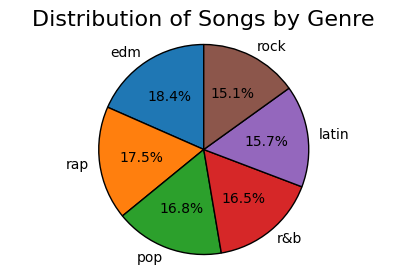

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Count the occurrences of each playlist genre
genre_counts = df_spotify['playlist_genre'].value_counts()

# Create the pie chart
plt.figure(figsize=(5, 3))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Songs by Genre', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Popularity distribution by genres.

#### Which visual would you recommend?

<Axes: xlabel='track_popularity', ylabel='Count'>

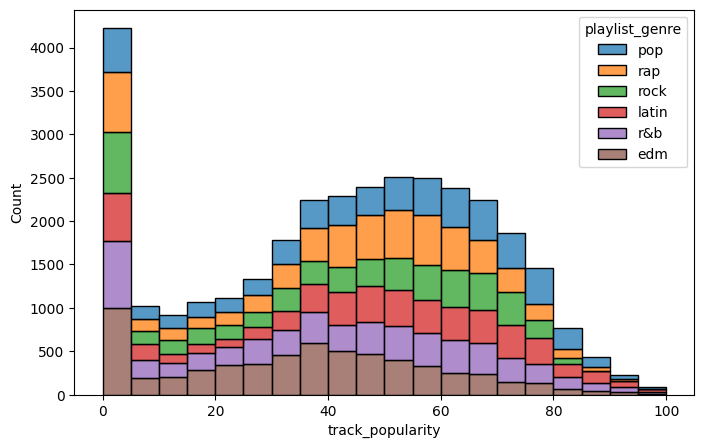

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(data=df_spotify, x='track_popularity',
             binwidth=5,
             hue='playlist_genre',
             multiple='stack')

### Pyramid Chart _  Compare popularity of songs from two different genres
A **pyramid chart** (also known as a population pyramid when used for demographics) is a type of bar chart that displays the distribution of a characteristic across two groups. It is particularly effective for comparing the frequency or distribution of a variable (e.g., `track_popularity`) across two distinct categories (e.g., `playlist_genre`).

In the provided code, `seaborn.histplot()` is ingeniously adapted to create a pyramid chart by leveraging specific parameters:

*   **`weights`**: A crucial parameter that assigns a 'weight' to each observation. For a pyramid chart, a common technique is to assign positive weights (e.g., `1`) to one category and negative weights (e.g., `-1`) to the other. This causes the bars for one category to extend in the opposite direction from the central axis.
*   **`stat='count'`**: Displays the count of observations in each bin. Combined with `weights`, this shows the count of items in each direction.
*   **`plt.axvline(0, color='black', linewidth=1)`**: Adds a vertical line at x=0, serving as the central axis from which the two distributions diverge, enhancing readability.

([<matplotlib.axis.XTick at 0x7cb1b6a47cb0>,
 [Text(-800.0, 0, '800'),
  Text(-600.0, 0, '600'),
  Text(-400.0, 0, '400'),
  Text(-200.0, 0, '200'),
  Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600')])

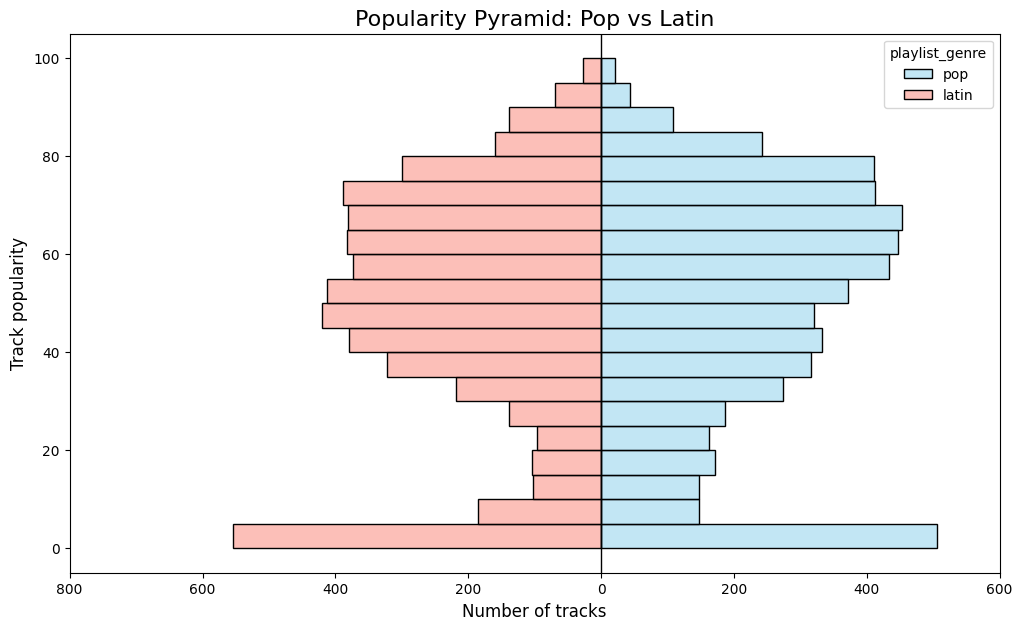

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter for 'pop' and 'latin' genres
df_pop_latin = df_spotify[df_spotify['playlist_genre'].isin(['pop', 'latin'])].copy()

# Assign signed weights
df_pop_latin['weight'] = df_pop_latin['playlist_genre'] \
.map({'latin':-1, 'pop':1})

plt.figure(figsize=(12, 7))

# Create the pyramid chart using histplot
sns.histplot(
    data=df_pop_latin,
    y='track_popularity',      # bins go here
    weights='weight',          # signed counts
    hue='playlist_genre',
    binwidth=5,
    stat='count',
    palette={'pop': 'skyblue', 'latin': 'salmon'},
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Number of tracks', fontsize=12)
plt.ylabel('Track popularity', fontsize=12)
plt.title('Popularity Pyramid: Pop vs Latin', fontsize=16)

# Get current x-axis tick locations and labels
locs, labels = plt.xticks()
# Update labels to show absolute values
plt.xticks(locs, [str(int(abs(loc))) for loc in locs])



### Question: Any findings?

##Part (4) About datetime format

* `df_spotify['track_album_release_date'] = pd.to_datetime(df_spotify['track_album_release_date'], errors='coerce', format='mixed')` converts the `track_album_release_date` column into a proper datetime format that Pandas can work with.

* `errors='coerce'` argument replaces any unparseable date values with `NaT` (Not a Time) instead of raising an error, allowing the process to continue.

* `format='mixed'` argument tells Pandas to try and infer the date format for each entry, which is useful when the column contains a mix of different date string formats (e.g., 'YYYY-MM-DD', 'YYYY').

* Once the column is converted to datetime objects, the `.dt` accessor provides an easy way to extract various date and time components. For example, `.dt.year` extracts the year, `.dt.month` extracts the month, and `.dt.to_period('M')` converts the datetime object into a Period object representing the month (e.g., 'YYYY-MM'), which is convenient for monthly analysis or grouping.

In [ ]:

# Convert 'track_album_release_date' to datetime, handling mixed formats and coercing errors
df_spotify['track_album_release_date'] = pd.to_datetime(df_spotify['track_album_release_date'], errors='coerce', format='mixed')

# Extract year, month, and year_month from the newly created datetime column
df_spotify['year'] = df_spotify['track_album_release_date'].dt.year
df_spotify['month'] = df_spotify['track_album_release_date'].dt.month
df_spotify['year_month'] = df_spotify['track_album_release_date'].dt.to_period('M') # Creates a Period object like 'YYYY-MM'

df_spotify.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,month,year_month
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,2019,6,2019-06
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,2019,12,2019-12
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2019,7,2019-07
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2019,7,2019-07
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,2019,3,2019-03


In [ ]:
# add an indicator to indentify zero popularity
df_spotify['zero'] = df_spotify['track_popularity']==0
df_spotify.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,month,year_month,zero
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.1020,0.000000,0.0653,0.518,122.036,194754,2019,6,2019-06,False
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0724,0.004210,0.3570,0.693,99.972,162600,2019,12,2019-12,False
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0794,0.000023,0.1100,0.613,124.008,176616,2019,7,2019-07,False
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0287,0.000009,0.2040,0.277,121.956,169093,2019,7,2019-07,False
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0803,0.000000,0.0833,0.725,123.976,189052,2019,3,2019-03,False


In [ ]:
# Identify tracks with zero popularity

df_spotify_zero = df_spotify[df_spotify['track_popularity'] == 0]

df_spotify_zero.shape

(2703, 27)

In [ ]:
# set aside the 0 popularity
df_spotify_p = df_spotify[df_spotify['track_popularity'] > 0]

### Question:

### It has been suggested that newer songs tend to have lower popularity, as popularity increases over time with accumulated streams. What visual would you recommend to check this claim?

<Axes: xlabel='year', ylabel='track_popularity'>

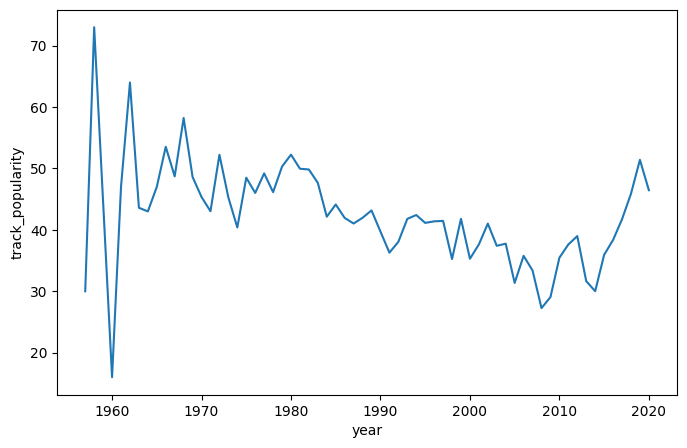

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# could it be that the newer songs are less popular?
plt.figure(figsize=(8, 5))

sns.lineplot(data=df_spotify,
             x=df_spotify['year'],
             y='track_popularity',
             errorbar=None)

## Part (5) Visualization comparing genres and comparing overall song features

### (5.1) Violin Chart for Popularity distribution by genres

A **violin chart** (or violin plot) is a method of plotting numeric data that shows the distribution of quantitative data across several categories. It is similar to a box plot, but it also displays the probability density of the data at different values (like a kernel density estimate), typically smoothed and symmetrical on both sides.

In the provided code, the key parameters used to generate the violin chart are:

*   **`inner='quartile'`**: This parameter adds markers inside the violins for the quartiles (25th, 50th, and 75th percentiles), similar to a mini box plot, providing additional summary statistics.
*   **`palette='pastel'`**: Sets the color scheme for the violins, using a predefined 'pastel' palette from Seaborn.
*   **`legend=False`**: Hides the legend, as the 'genre' labels on the x-axis already provide sufficient information about the categories.

Note: A violin plot mirrors the same density on both sides.

Build a violin chart for track popularity distribution by genres.

<Axes: xlabel='playlist_genre', ylabel='track_popularity'>

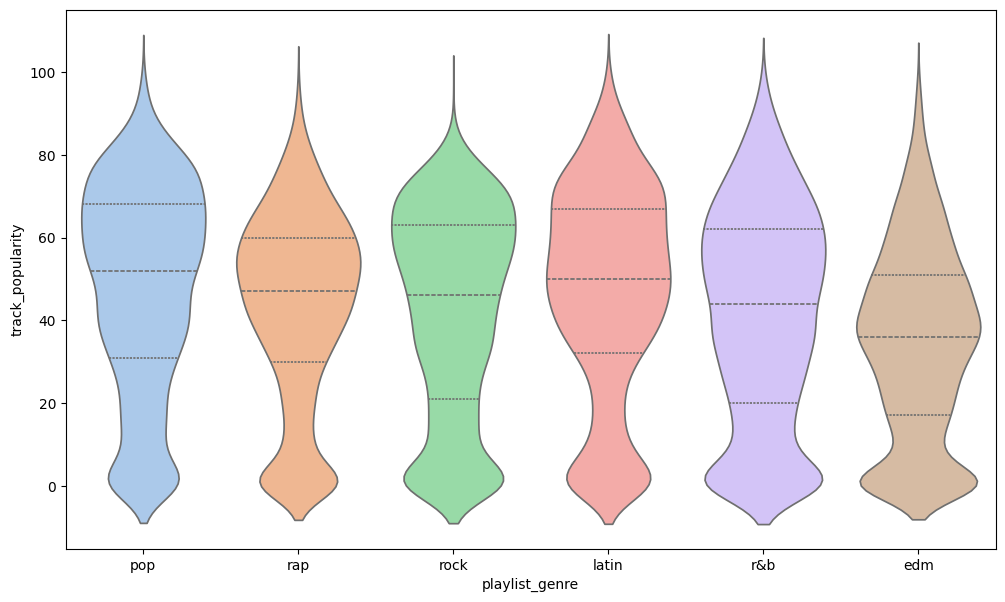

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a violin chart of danceability by genre
plt.figure(figsize=(12, 7))
sns.violinplot(data=df_spotify, x='playlist_genre', y='track_popularity', inner='quartile', palette='pastel', hue='playlist_genre', legend=False)

Calculate the compare means of various metrics across genres and zero/nonzero poularity.

In [ ]:
df_spotify.groupby(['playlist_genre', 'zero']).agg({
    'track_popularity':'mean',
    'danceability':'mean',
    'loudness':'mean',
    'year':'mean'
})

track_popularity  danceability  loudness         year
playlist_genre zero                                                        
edm            False         39.537754      0.656072 -5.487489  2016.997746
               True           0.000000      0.647405 -4.982834  2014.079277
latin          False         50.504583      0.713254 -6.198140  2015.019167
               True           0.000000      0.713738 -7.161110  2009.946479
pop            False         50.622064      0.642517 -6.312078  2014.541009
               True           0.000000      0.585952 -6.369256  2011.386581
r&b            False         45.320850      0.668446 -7.841731  2009.724696
               True           0.000000      0.687619 -8.097430  2005.741344
rap            False         46.763842      0.720700 -7.102283  2012.919586
               True           0.000000      0.689764 -6.311369  2010.316514
rock           False         45.286497      0.522718 -7.532298  1996.871767
               True           0.000000      0.495100 -8.252632  2001.668380

### (5.2) Heatmaps _ Analyze the audio features

A **heatmap** is a graphical representation of data where individual values contained in a matrix are represented as colors. It's particularly useful for visualizing correlation matrices, showing patterns of similarity or intensity, and detecting outliers across a dataset. In business analytics, heatmaps are excellent for quickly identifying relationships between variables, such as product sales across different regions, customer engagement with various features, or, as often used, the correlation between different features in a dataset.

Key parameters commonly used in Seaborn's `heatmap()` function include:

*   **`data`**: The rectangular dataset (e.g., a Pandas DataFrame or a correlation matrix) to be plotted. Each cell's value in this dataset will determine its color.
*   **`annot`**: If `True`, the data value is printed in each cell. This is very useful for correlation matrices where you want to see the exact correlation coefficient.
*   **`fmt`**: String formatting code to use when `annot` is `True`. For example, `'.2f'` formats numbers to two decimal places.
*   **`cmap`**: The colormap to use for mapping data values to colors. Examples include `'coolwarm'` (good for divergent data like correlations), `'viridis'`, `'plasma'`, `'magma'`, `'Blues'`, etc.
*   **`linewidths`**: The width of the lines that divide each cell.
*   **`linecolor`**: The color of the lines that divide each cell.
*   **`cbar`**: If `True` (default), a color bar is drawn to show the color mapping. Setting it to `False` hides the color bar.
*   **`vmin`, `vmax`**: Values to anchor the colormap, otherwise, they are inferred from the data. Useful for keeping color scales consistent across multiple plots.

In [ ]:
## Check info and identify variables for heatmap
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   track_id                  32833 non-null  object        
 1   track_name                32828 non-null  object        
 2   track_artist              32828 non-null  object        
 3   track_popularity          32833 non-null  int64         
 4   track_album_id            32833 non-null  object        
 5   track_album_name          32828 non-null  object        
 6   track_album_release_date  32833 non-null  datetime64[ns]
 7   playlist_name             32833 non-null  object        
 8   playlist_id               32833 non-null  object        
 9   playlist_genre            32833 non-null  object        
 10  playlist_subgenre         32833 non-null  object        
 11  danceability              32833 non-null  float64       
 12  energy            

In [ ]:
# obtain audio feature with popularity
df_audio = df_spotify.iloc[:,[3,*range(11,23)]]
df_audio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_popularity  32833 non-null  int64  
 1   danceability      32833 non-null  float64
 2   energy            32833 non-null  float64
 3   key               32833 non-null  int64  
 4   loudness          32833 non-null  float64
 5   mode              32833 non-null  int64  
 6   speechiness       32833 non-null  float64
 7   acousticness      32833 non-null  float64
 8   instrumentalness  32833 non-null  float64
 9   liveness          32833 non-null  float64
 10  valence           32833 non-null  float64
 11  tempo             32833 non-null  float64
 12  duration_ms       32833 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 3.3 MB


<Axes: >

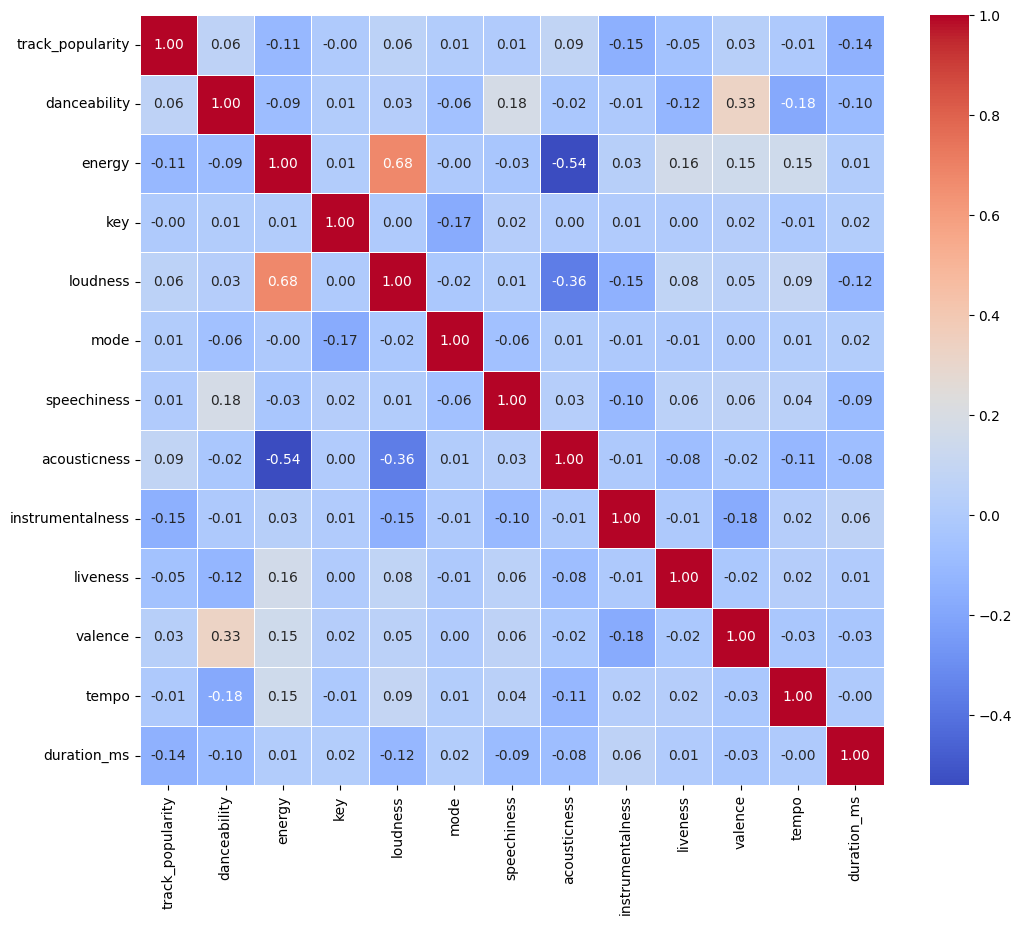

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate the correlation matrix
correlation_matrix = df_audio.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=True)



### Question. Examine the heatmap and pick a pair of variables that show a correlation that makes sense to you. Are there any correlations that appear counterintuitive?

### Understanding Seaborn Color

**cmap** (colormap) is generally used when you want to map a continuous numerical variable to a gradient of colors. This is why you see it used in sns.heatmap() or sns.histplot() for the hue parameter, where a range of values is represented by a gradual change in color. For example, in a heatmap of correlations, higher correlations might be darker red, while lower ones are lighter blue.

**palette** is used when you want to assign discrete colors to distinct categories. In sns.scatterplot(), when you use the hue parameter to color points based on a categorical variable (like playlist_genre), you would use palette to specify the set of colors for each category. Each genre would get its own distinct color from the palette.

Seaborn categorizes colormaps into several types:

1.  **Sequential Palettes**: These are suitable for data that progresses from low to high values. They typically use a gradient of a single color or a smooth transition between two similar colors. Examples include `'Blues'`, `'Greens'`, `'Reds'`, `'viridis'`, `'plasma'`, `'inferno'`, `'magma'`. Ideal for showing intensity or quantity.

2.  **Diverging Palettes**: These are used for data where there is a meaningful mid-point (e.g., zero, average) and values diverge in two directions from this center. They typically use two contrasting colors with a neutral color in the middle. Examples include `'coolwarm'`, `'RdBu'`, `'PuOr'`. Excellent for visualizing correlations or differences from a baseline.

3.  **Qualitative Palettes**: These are best for distinguishing between discrete categories where there is no inherent order. They consist of distinct colors that are easily discriminable. Examples include `'Set1'`, `'Paired'`, `'tab10'`, `'pastel'`. Useful for showing different groups or types.

4.  **Custom Palettes**: You can also create custom color palettes using `sns.color_palette()` or pass a list of colors directly.

**Note:**

When you pass a numeric column (like loudness or track_popularity in your example) to the hue parameter in sns.scatterplot(), Seaborn intelligently understands that it's continuous data. In this scenario, it automatically generates a sequential colormap (similar to what cmap would explicitly do) to represent the range of values in that numeric column. So, for loudness, darker or lighter shades of a color (or a gradient from one color to another, as defined by a default or specified cmap) would be used to indicate higher or lower loudness values.

Essentially:

* If hue is categorical, Seaborn uses a palette (a set of distinct colors).
* If hue is numerical, Seaborn uses a cmap (a continuous color gradient).


### (5.3) Bubble chart

A bubble chart is a variation of a scatter plot where each point is drawn as a circle (a “bubble”) whose position, size, and often color encode different variables. It's a compact way to visualize three or more quantitative variables at once.

**Core idea**

Plot points on an X-Y plane like a scatter plot, use the bubble area (or radius) to represent a third numeric variable, and use color (hue or intensity) to show a fourth variable (categorical or numeric).

However, this is not ideal when you have many overlapping points, or when precise comparison of the third variable is required (humans are bad at comparing areas precisely).

How to map variables

*  X axis: primary independent variable (numeric or ordinal).
*  Y axis: primary dependent variable (numeric).
*  Bubble size: numeric variable (commonly mapped to area, not radius).
*  Color: can encode a categorical variable (distinct hues) or a numeric variable (sequential or diverging colormap). Use color to highlight grouping or a separate quantitative measure.



In [ ]:
# summary table of average audio feature and year
df_spotify_summary = df_spotify.groupby('year', as_index=False).agg({
    'track_popularity':'mean',
    'loudness':'mean',
    'valence':'mean',
})

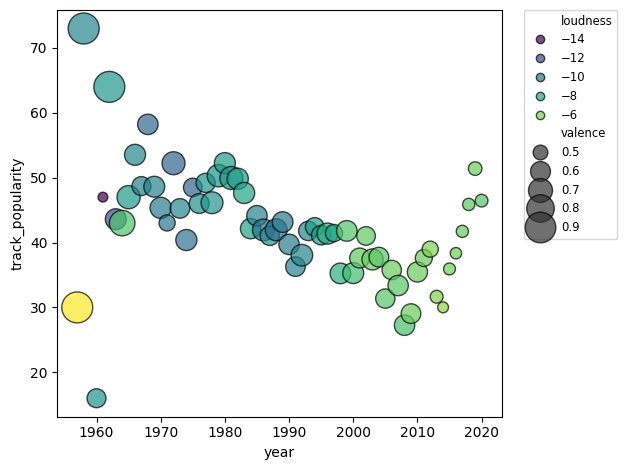

In [ ]:
sns.scatterplot(data=df_spotify_summary,
                x='year',
                y='track_popularity',
                hue='loudness',
                size='valence',
                sizes=(50, 500),
                alpha=0.7,
                palette='viridis',
                edgecolor='black',
                linewidth=1
                )
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize='small')
plt.tight_layout()


### Q&A Based on the bubble chart, on average, how have songs changed over the years in terms of loudness and valence?

### (5.4) (Optional) Radar chart: Comparing key features of songs from different genre.
### Radar Chart with Plotly's `line_polar`

A **radar chart**, also known as a spider chart or web chart, is an effective visualization tool for displaying multivariate data on a two-dimensional plane. It is particularly useful for comparing multiple quantitative variables (features) across different categories or entities. Each variable is represented by an axis radiating from the center, and the values are plotted along these axes, forming a polygon for each category.

While Matplotlib can be used to construct radar charts with its `polar` projection, the `plotly` library offers a more straightforward and interactive approach, especially with its `px.line_polar` function. Plotly charts are interactive, allowing users to hover over data points, zoom, and pan, which can greatly enhance data exploration.

#### Workflow to Build a Radar Chart using Plotly `px.line_polar`:
1.  **Filter Data**: Select the relevant subset of your DataFrame based on specific criteria (e.g., years, popularity).
2.  **Select Features**: Identify the quantitative variables you want to compare on the radar chart (e.g., 'loudness', 'danceability', 'valence').
3.  **Group and Aggregate**: Group the data by the categorical variable you wish to compare (e.g., `playlist_genre` or `year`) and calculate the mean (or another aggregate statistic) for each selected feature.
4.  **Normalize Data**: Radar charts require all features to be on a similar scale for meaningful comparison. Use a scaling technique like Min-Max Scaling (`sklearn.preprocessing.MinMaxScaler`) to transform feature values to a common range, typically 0 to 1.
5.  **Melt DataFrame (for Plotly)**: Plotly's `px.line_polar` function works best when the data is in a 'long' format. Melt your normalized DataFrame so that features become a single column (`var_name='Feature'`) and their corresponding normalized values become another column (`value_name='Value'`).
6.  **Create Chart**: Use `px.line_polar` to generate the radar chart.

#### Key Parameters for `plotly.express.line_polar`:
*   **`data_frame`**: The melted DataFrame containing the data to be plotted.
*   **`r`**: The column name in `data_frame` that specifies the radial distance (the 'value' column from the melted DataFrame).
*   **`theta`**: The column name in `data_frame` that specifies the angular position (the 'feature' column from the melted DataFrame).
*   **`color`**: The column name in `data_frame` that dictates how to color the lines, typically the categorical variable you are comparing (e.g., 'playlist_genre' or 'year').
*   **`line_close`**: A boolean (default `True`) that closes the line segments to form a polygon, which is characteristic of radar charts.
*   **`title`**: A string for the chart's title.
*   **`fill`**: Sets the fill area for the polygons. Common values include `'toself'` (fills the area to itself) or `'none'`.

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# 1. Filter df_spotify_p for songs produced between 2015 and 2019
df_radar_data = df_spotify_p[(
    (df_spotify_p['year'] >= 2015) &
    (df_spotify_p['year'] <= 2019)
)].copy()

# 2. Select the specified features for the radar chart
features = ['track_popularity', 'loudness', 'duration_ms', 'valence', 'danceability', 'instrumentalness']

# 3. Group by playlist_genre and calculate the mean for each selected feature
df_grouped_by_genre = df_radar_data.groupby('playlist_genre')[features].mean().reset_index()

# 4. Normalize the data (Min-Max Scaling) to bring all features to a 0-1 scale
scaler = MinMaxScaler()
# Apply scaler to only the feature columns
df_normalized_features = scaler.fit_transform(df_grouped_by_genre[features])

# Create a DataFrame for normalized features, keeping the 'playlist_genre' column
df_normalized_for_plot = pd.DataFrame(df_normalized_features, columns=features)
df_normalized_for_plot['playlist_genre'] = df_grouped_by_genre['playlist_genre']

# Prepare data for Plotly radar chart
# Plotly expects the categories (features) to be a column, and each row a 'series' (genre)
# So, we'll melt the dataframe to have 'feature' and 'value' columns
df_melted = df_normalized_for_plot.melt(id_vars=['playlist_genre'], var_name='Feature', value_name='Value')


# Create the Plotly radar chart
fig = px.line_polar(
    df_melted,
    r='Value',
    theta='Feature',
    color='playlist_genre',
    line_close=True,
    title='Average Normalized Song Features by Playlist Genre (2015-2019)',
    #color_discrete_sequence=px.colors.qualitative.Set1 # Changed to Set1 for another distinct contrast
)

#fig.update_traces(opacity=0.7)
# If you don't want to use default color, you may use the following to change the color.
import re

alpha = 0.25
palette = px.colors.qualitative.Set1

for i, trace in enumerate(fig.data):
    color = palette[i % len(palette)]

    # extract numbers from "rgb(r, g, b)"
    r, g, b = map(int, re.findall(r"\d+", color))

    trace.update(
        fill="toself",
        line_color=color,
        marker_color=color,
        fillcolor=f"rgba({r},{g},{b},{alpha})"
    )


fig.show()

## Part (6) Analyze songs in the pop genre

Select songs in th pop genre.

In [ ]:
df_pop = df_spotify[df_spotify['playlist_genre'] == 'pop'].copy()
df_pop.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,month,year_month,zero
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.1020,0.000000,0.0653,0.518,122.036,194754,2019,6,2019-06,False
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0724,0.004210,0.3570,0.693,99.972,162600,2019,12,2019-12,False
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0794,0.000023,0.1100,0.613,124.008,176616,2019,7,2019-07,False
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0287,0.000009,0.2040,0.277,121.956,169093,2019,7,2019-07,False
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0803,0.000000,0.0833,0.725,123.976,189052,2019,3,2019-03,False


### (6.1) Overview of popularity vs. number of songs using using line with bar

In [ ]:
# Filter df_pop for songs from 2005
df_pop_05_20 = df_pop[df_pop['year'] >= 2005].copy()

# Calculate number of songs per year
song_counts_per_year = df_pop_05_20['year'].value_counts().sort_index().reset_index()
#song_counts_per_year.columns = ['year', 'count']
song_counts_per_year

,year,count
0,2005,22
1,2006,50
2,2007,50
3,2008,112
4,2009,95
5,2010,173
6,2011,144
7,2012,176
8,2013,227
9,2014,316


In [ ]:
df_pop_05_20 = df_pop[df_pop['year'] >= 2005].copy()
pop_summary = df_pop_05_20\
.groupby('year')['track_popularity']\
.agg(['mean','count'])\
.sort_index()\
.reset_index()
pop_summary

,year,mean,count
0,2005,41.454545,22
1,2006,31.580000,50
2,2007,48.240000,50
3,2008,35.553571,112
4,2009,30.336842,95
5,2010,42.369942,173
6,2011,48.493056,144
7,2012,52.852273,176
8,2013,46.290749,227
9,2014,41.759494,316


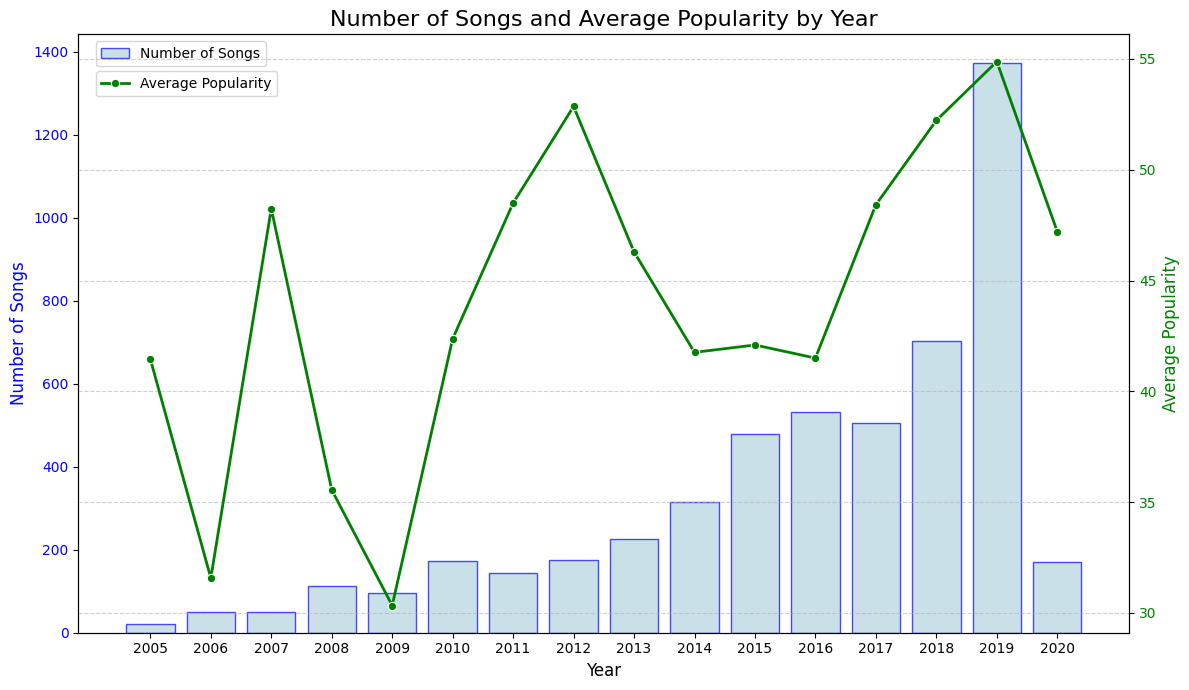

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add year_str for plotting
pop_summary['year_str'] = pop_summary['year'].astype(str)

# Create a figure and a set of subplots with a shared x-axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot bar chart on ax1 (number of songs)
sns.barplot(
    x='year_str', # Use the string version of year, using numeric year is also okay with the bar
    y='count',
    data=pop_summary,
    ax=ax1,
    edgecolor='blue',
    color='lightblue',
    alpha=0.7,
    label='Number of Songs'
)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Songs', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Number of Songs and Average Popularity by Year', fontsize=16)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot line chart on ax2 (average popularity)
sns.lineplot(
    x='year_str', # Use the string version of year, do not use numeric year here
    y='mean',
    data=pop_summary,
    ax=ax2,
    color='green',
    marker='o',
    linewidth=2,
    label='Average Popularity'
)
ax2.set_ylabel('Average Popularity', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

# set legend position
ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1))
ax2.legend(loc='upper left', bbox_to_anchor=(0.01, 0.95))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Are there difference between the most popular and the least popular songs?

Build the following two subsets:

* (1) Pop songs with high popularity
* (2) Pop songs with low popularity

Categorize song popularity as follow:

* High, if popularity > 75
* Low, if popularity < 15
* Medium, if popularity is at least 15 but no more than 75

In [ ]:
# Identify comparison group
# Embed the if-elif-else logic directly into the .map() function using a lambda
df_pop['cat'] = df_pop['track_popularity'].map(lambda popularity:
    'high' if popularity > 75
    else ('low' if popularity < 15
    else 'medium')
)
df_pop['cat'].value_counts()


,count
cat,
medium,3958
low,800
high,749


### (6.2) Comparing popular and unpopular songs using Diverging Bar Charts

A **diverging bar chart**, often used as a 'spine chart' or 'butterfly chart', is a powerful visualization tool for comparing two categories against a common baseline or for showing the deviation of values from a central point. It is particularly effective for presenting survey data (e.g., agreement vs. disagreement), comparing performance metrics (e.g., above vs. below average), or, as in our case, highlighting differences between two distinct groups (e.g., 'high' vs. 'low' popularity) relative to an overall average.

#### General Workflow for Creating a Diverging Bar Chart:
1.  **Identify Comparison Groups**: Determine the two groups you want to compare (e.g., 'high' and 'low' popularity). These will form the opposing bars.
2.  **Define a Baseline**: Establish a central reference point, such as an overall average or a neutral value, from which deviations will be measured.
3.  **Calculate Deviations**: For each item or feature, calculate how much each comparison group's value deviates from the baseline.
4.  **Prepare Data for Plotting**: Organize your data into a 'long' format suitable for plotting, typically with columns for the item/feature, the comparison group, and the calculated deviation.
5.  **Plot with Diverging Colors**: Use a bar plotting function, typically from `seaborn` or `matplotlib`, and assign distinct, contrasting colors to the two comparison groups. Place a vertical line at the baseline (often zero) to emphasize the divergence.

#### Key Parameters for `seaborn.barplot()` in a Diverging Context:
*   **`data`**: The DataFrame containing your data, preferably in a 'long' format.
*   **`x`**: The column representing the deviations (values that diverge from the center).
*   **`y`**: The column representing the items or features being compared (often categorical).
*   **`hue`**: The column that differentiates the two comparison groups (e.g., 'High Popularity Deviation', 'Low Popularity Deviation'). This is crucial for assigning distinct colors to each side of the divergence.
*   **`palette`**: A dictionary or list of colors to explicitly set the colors for each `hue` category. Choosing contrasting colors (e.g., blue for positive, red for negative) enhances readability.
*   **`errorbar=None`**: Typically set to `None` when plotting pre-calculated means or deviations, as confidence intervals are not usually relevant in this context.
*   **`dodge=True`**: When `x` and `hue` are used, `dodge=True` (the default for `barplot` when `hue` is present) positions bars side-by-side. For a true diverging chart, where bars extend in opposite directions from a central line, the `x` values for one `hue` category would be negative, creating the desired visual effect.
*   **`plt.axvline(0, color='gray', linestyle='--')`**: A `matplotlib` function used to draw a vertical line at `x=0`, clearly indicating the central baseline from which values diverge.

Let’s use diverging bars to compare audio features of songs with high and low popularity.

Here is the list of features for your convenience.

```
    'loudness':'mean',
    'valence':'mean',
    'duration_ms':'mean',
    'danceability':'mean',
    'instrumentalness':'mean',
    'energy':'mean',
    'speechiness':'mean',
    'acousticness':'mean',
    'liveness':'mean',
    'tempo':'mean'
```

In [ ]:
pop_feature = df_pop.groupby(['cat']) \
.agg({
    'loudness':'mean',
    'valence':'mean',
    'duration_ms':'mean',
    'danceability':'mean',
    'instrumentalness':'mean',
    'energy':'mean',
    'speechiness':'mean',
    'acousticness':'mean',
    'liveness':'mean',
    'tempo':'mean'
}).round(2).T \
.reset_index().rename(columns={'index': 'feature'})

display(pop_feature)

cat,feature,high,low,medium
0,loudness,-5.68,-6.57,-6.38
1,valence,0.53,0.51,0.50
2,duration_ms,211693.98,232996.77,215839.50
3,danceability,0.67,0.62,0.64
4,instrumentalness,0.01,0.09,0.06
5,energy,0.68,0.72,0.70
6,speechiness,0.08,0.07,0.07
7,acousticness,0.19,0.15,0.17
8,liveness,0.16,0.18,0.18
9,tempo,118.80,122.27,120.80


### Question about standardization

Two different approaches can be used to prepare data for a diverging bar chart comparing audio features of songs with high (H) and low (L) popularity:

* **Approach 1:** Standardize the entire dataset first so that the grand mean is approximately zero. Then, for each group (H and L), calculate the mean of the standardized values. These group means are compared against zero to show how far each group deviates from the overall average.

* **Approach 2:** First, separate the data into High (H), Medium (M), and Low (L) popularity groups. Standardize each group independently and compute the mean for each group. The grand mean is then defined as the average of the three group means, and deviations of H and L from this grand mean are compared.

**Question:**
Which approach is more appropriate for creating a diverging bar chart that compares high- and low-popularity songs, and why? Consider how each method defines the reference point and how that affects interpretation.



### Standardization vs. Normalization in Python

Standardization and normalization are two common data preprocessing techniques used to scale numerical features. While both aim to transform data to a common scale, they achieve this through different methods and are suitable for different scenarios.

### 1. Standardization (Z-score Normalization)

**What it does**: Standardization (or Z-score normalization) transforms data to have a mean of 0 and a standard deviation of 1. It scales features such that they have the properties of a standard normal distribution (μ=0, σ=1), where the mean is centered around zero and the data points are represented in terms of standard deviations from the mean.

**Mathematical Formula**:
For each data point $x_i$, the standardized value $x'_i$ is calculated as:

$x'_i = (x_i - \mu) / \sigma$

Where:
*   $x_i$ is the original feature value.
*   $\mu$ is the mean of the feature.
*   $\sigma$ is the standard deviation of the feature.

**When to use**: Standardization is particularly useful when the features have different scales, but the data distribution is approximately Gaussian (bell-shaped). It's also robust to outliers, as it doesn't bound the values to a specific range, allowing outliers to retain their relative distance from the mean. Many machine learning algorithms (e.g., SVMs, Logistic Regression, PCA) assume that data is normally distributed or perform better when features are on a similar scale.

**Scikit-learn Function**:
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)
# 'data' should be a NumPy array or pandas DataFrame
```

### 2. Normalization (Min-Max Scaling)

**What it does**: Normalization (or Min-Max scaling) scales features to a fixed range, typically between 0 and 1. It compresses the data into a specific interval, usually when you know the approximate minimum and maximum values of the feature.

**Mathematical Formula**:
For each data point $x_i$, the normalized value $x'_i$ is calculated as:

$x'_i = (x_i - X_{min}) / (X_{max} - X_{min})$

Where:
*   $x_i$ is the original feature value.
*   $X_{min}$ is the minimum value of the feature.
*   $X_{max}$ is the maximum value of the feature.

**When to use**: Normalization is beneficial when algorithms do not assume any distribution of the data (e.g., K-Nearest Neighbors, neural networks) or when features need to be constrained within a strict interval. However, it is sensitive to outliers, as a single outlier can significantly compress the majority of the data into a small range.

**Scikit-learn Function**:
```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)
# 'data' should be a NumPy array or pandas DataFrame
```

### Key Differences:

*   **Output Range**: Standardization does not bound values to a specific range, while normalization typically scales values between 0 and 1 (or any specified range).
*   **Sensitivity to Outliers**: Normalization is more affected by outliers, as they directly influence the min and max values. Standardization is less affected by outliers, as it only uses the mean and standard deviation.
*   **Distribution Assumption**: Standardization assumes a Gaussian-like distribution, making it suitable for algorithms that benefit from it. Normalization does not assume any particular distribution.
*   **Application**: Choose standardization if your data has outliers or if your algorithm assumes normal distribution. Choose normalization if your data is not skewed by outliers or if your algorithm requires features to be within a specific range.

Below is the list of numeric features we will use.

```
'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
```

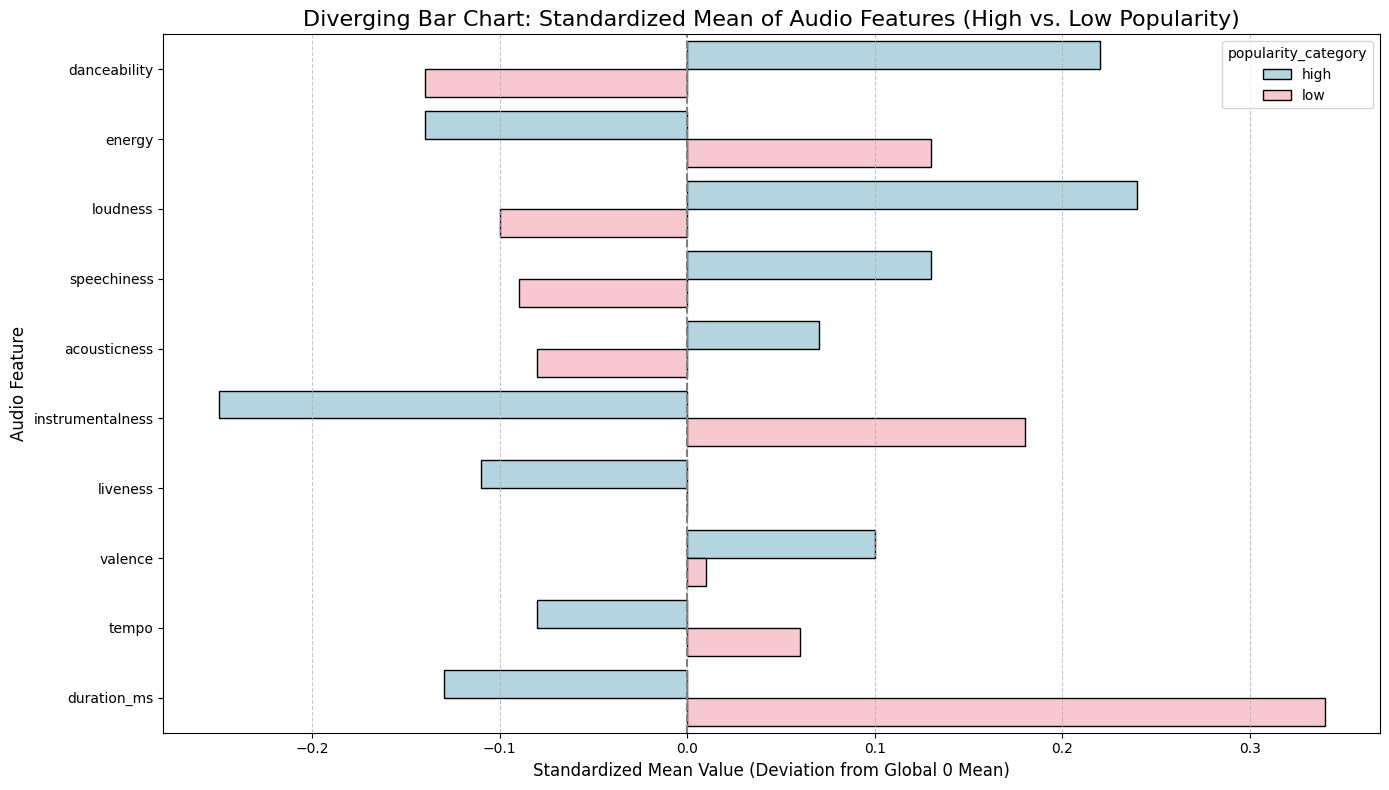

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler # for standardization

# Create a copy to avoid modifying the original df_pop directly for this operation
df_pop_normalized_features = df_pop.copy()

# Identify numeric columns (excluding 'track_popularity' and 'cat')
numeric_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply normalization to each numeric feature across the entire DataFrame (regardless of cat)
df_pop_normalized_features[numeric_features] = scaler.fit_transform(df_pop_normalized_features[numeric_features])

# Now, calculate the mean of these globally normalized features grouped by 'cat'
# This will be our pop_feature equivalent for normalized data
df_for_diverging = df_pop_normalized_features.groupby('cat')[numeric_features].mean().round(2).T

# In this case, since data is standardized globally, the overall mean is approximately 0. We can directly use the 'high' and 'low' standardized means as their deviations from 0.

# Reset index to make 'feature' a regular column for plotting
df_for_diverging = df_for_diverging.reset_index().rename(columns={'index': 'feature'})

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted_deviations = df_for_diverging.melt(
    id_vars=['feature'],
    value_vars=['high', 'low'],
    var_name='popularity_category',
    value_name='deviation'
)

plt.figure(figsize=(14, 8)) # Adjust figure size for better readability

# Create the diverging bar chart
sns.barplot(
    data=df_melted_deviations,
    x='deviation',       # Deviation on the x-axis
    y='feature',         # Features on the y-axis
    hue='popularity_category', # Differentiate 'high' and 'low' deviations
    palette={'high': 'lightblue', 'low': 'pink'},
    errorbar=None,       # No error bars as we're plotting calculated means
    dodge=True,           # Display bars for 'high' and 'low' side-by-side
    edgecolor='black'
)

# Add a vertical line at x=0 to emphasize deviations (which is now the global mean)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

plt.title('Diverging Bar Chart: Standardized Mean of Audio Features (High vs. Low Popularity)', fontsize=16) # Updated title
plt.xlabel('Standardized Mean Value (Deviation from Global 0 Mean)', fontsize=12) # Updated label
plt.ylabel('Audio Feature', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.legend(title='Popularity Category', bbox_to_anchor=(1.05, 1), loc='upper left') #if you wish to position the ledgend out of the chart
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This `melt()` call is taking your `df_for_diverging` DataFrame, keeping the `feature` column as is, and then transforming the `high` and `low` columns. It creates a new column called `popularity_category` (containing 'high' or 'low') and another new column called `deviation` (containing the corresponding numerical mean value from the original 'high' or 'low' columns). This prepares the data perfectly for creating grouped bar plots or diverging charts where you want to compare these two popularity categories for each feature.

### Example for `pandas.melt()`

The `pandas.melt()` function converts data from a 'wide' format to a 'long' format.

**Before `melt()` (Wide Format):**

Imagine a DataFrame like this, tracking scores for different subjects:

```
  Student  Math  Science
0     Alice    90       85
1       Bob    75       80
```

**After `melt()` (Long Format):**

If we `melt()` this DataFrame, keeping 'Student' as an ID variable and melting 'Math' and 'Science', it transforms into:

```
  Student  variable  value
0     Alice      Math     90
1       Bob      Math     75
2     Alice   Science     85
3       Bob   Science     80
```

Here, the 'Math' and 'Science' columns are 'unpivoted' into new rows. A new column, 'variable' (default name), indicates the original column name (e.g., 'Math'), and 'value' (default name) contains the corresponding score. This 'long' format is often easier for plotting and analysis.

#### Question: What other visuals would you proposed to compare high popularity songs and low popularity songs?

### (6.3) (Optional) Studying particular features of songs in pop genre using Ridgeline Plot (Joyplot)

A **ridgeline plot**, also known as a **joyplot**, is a visualization technique that displays the distribution of a quantitative variable for several groups, with the distributions typically overlapping. It is particularly effective for visualizing changes in distributions over time or across ordered categories, providing a sense of 'flow' or 'evolution' in the data.

To create a ridgeline plot, we essentially:
1.  Filter the data to the relevant variables and sort by the grouping variable (e.g., year).
2.  For each group (year), calculate the Kernel Density Estimate (KDE) of the quantitative variable (e.g., danceability).
3.  Plot each KDE curve, often filling the area beneath it, and apply a vertical offset to each subsequent plot to create the overlapping effect. This offset (`overlap`) is key to the ridgeline appearance.

Key elements in the code will include:
*   `seaborn.kdeplot()`: To estimate and plot the density for each year.
*   `matplotlib.pyplot.subplots()`: To create the main figure and axes.
*   Iteration: Looping through each unique year to draw its respective KDE curve.
*   `vertical offset`: Applying a calculated `offset` to `y` values for each KDE to achieve the staggered, overlapping effect.
*   `fill=True`: To shade the area under each density curve.

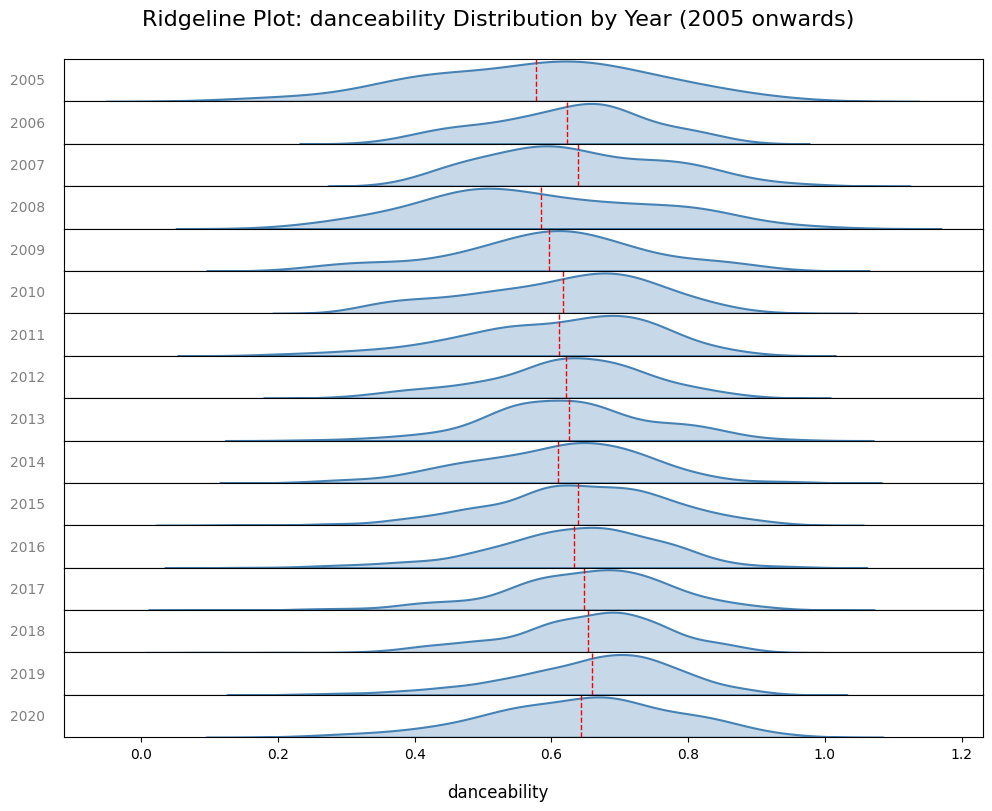

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Filter relevant columns and sort by year for proper ridgeline order
df_filtered = df_pop[['year', 'danceability']].sort_values('year').copy()

# Filter years to start from 2005
df_filtered = df_filtered[df_filtered['year'] >= 2005]

# Get unique years for iteration
all_years = df_filtered['year'].unique()

# Set up the plot: narrow width, adaptive height based on number of all_years
# Adjusted hspace to a negative value for overlap and sharey=True for consistent y-scale
fig, axes = plt.subplots(figsize=(10, max(6, len(all_years) * 0.5)),
                         nrows=len(all_years), sharex=True, sharey=False,
                         gridspec_kw={'hspace': 0}) # Adjusted hspace and added sharey=True

# Ensure axes is iterable even if there's only one year
if len(all_years) == 1:
    axes = [axes]

# Loop through each year and plot KDE
for i, year in enumerate(all_years):
    ax = axes[i]

    # Select data for the current year
    data_year = df_filtered[df_filtered['year'] == year]['danceability']

    # Plot KDE with fill and outline
    sns.kdeplot(
        x=data_year,
        ax=ax,
        fill=True,
        color='steelblue',
        alpha=0.3,
        linewidth=1.5 # Ensures a clear density outline
    )

    # Calculate and add mean line
    ax.axvline(data_year.mean(), color='red', linestyle='--', linewidth=1) # Add mean line

    # Set year label
    ax.text(
        -0.02, 0.5, str(year),
        transform=ax.transAxes,
        ha='right',
        va='center',
        fontsize=10,
        color='gray'
    )
    ax.set_yticks([])
    ax.set_ylabel('') # Remove default 'density' label
    ax.set_xlabel('') # Remove x-label for individual subplots

# Set common x-axis label
fig.supxlabel('danceability', fontsize=12)
# Adjust suptitle to reflect actual plotting years
fig.suptitle(f'Ridgeline Plot: danceability Distribution by Year ({min(all_years)} onwards)', y=1.00, fontsize=16)

plt.tight_layout() # Removed rect argument for more flexibility
plt.show()

## Part (7) Time series analysis

### (7.1) Time Series Analysis: Introduction

Time series analysis is a specialized branch of statistics and data science focused on analyzing data points collected over a period of time. The primary goal is to understand patterns, trends, and seasonality within the data to improve forecasts, identify anomalies, and gain insights into the underlying processes generating the observations. Unlike cross-sectional data, time series data inherently has a temporal order, meaning the sequence of observations is crucial. This sequential dependency often leads to techniques that account for past values influencing future ones, such as autocorrelation and lag. Applications span diverse fields, from predicting stock prices and forecasting demand to understanding consumer behavior and disease outbreaks.

### Moving Averages and Business Applications

A **moving average (MA)** is a simple and widely used technique in time series analysis to smooth out short-term fluctuations and highlight longer-term trends or cycles. It calculates the average of a specific number of consecutive data points, and then 'moves' that window of data points forward over time. In business, moving averages are invaluable for understanding underlying sales trends, stock price movements, or website traffic patterns by reducing day-to-day 'noise'. They are often used for **forecasting**, where a future value is predicted based on the average of recent past values.

To evaluate the accuracy of forecasting models, including those using moving averages, the **Mean Absolute Deviation (MAD)** is a commonly used metric. MAD measures the average magnitude of the errors in a set of forecasts, without considering their direction. It is calculated as the average of the absolute differences between actual and forecasted values. A lower MAD indicates a more accurate forecast. While not directly a standard deviation, MAD is conceptually related to the **Standard Deviation (SD) of the forecast error**. For a normally distributed forecast error, the SD is approximately 1.25 times the MAD ($\sigma \approx 1.25 \times \text{MAD}$). This relationship allows forecasters to estimate the SD of errors from MAD, which can then be used to construct prediction intervals and assess forecast reliability.

#### Understanding Rolling Window Options

When calculating a moving average (MA) with Pandas' `.rolling()` method, the `center` parameter dictates how the window is aligned:

*   **`center=True`**: The window is centered on the current data point. For an odd-sized window (e.g., `window=3`), the average for a specific year (e.g., 2015) will include the values from the previous year (2014), the current year (2015), and the next year (2016).

*   **`center=False` (default)**: The window is aligned to the right, meaning the current data point is the last element in the window. For a `window=3`, the MA for 2015 would be the average of 2013, 2014, and 2015. This is useful when you want to compute a statistic based only on past and current observations.

*   **Lagged Moving Average**: If you want the MA(3) for 2015 to represent the average of *only* previous years (e.g., 2012, 2013, 2014), you would typically combine the `.rolling()` method with a `.shift()` operation. First, calculate the rolling average with `center=False`, and then use `.shift(n)` (where `n` is the number of periods to shift) to move the calculated average to the desired past year. For example, `df['value'].rolling(window=3, center=False).mean().shift(1)` would give you an MA for 2015 that includes 2012, 2013, and 2014 (by shifting the 2014 average, which originally covered 2012-2014, to 2015).

Summary example:
| Method                           | Years used for MA at 2015 |
| -------------------------------- | ------------------------- |
| `rolling(3).mean()`              | 2013, 2014, 2015          |
| `rolling(3).mean().shift(1)`     | 2012, 2013, 2014          |
| `rolling(3, center=True).mean()` | 2014, 2015, 2016          |


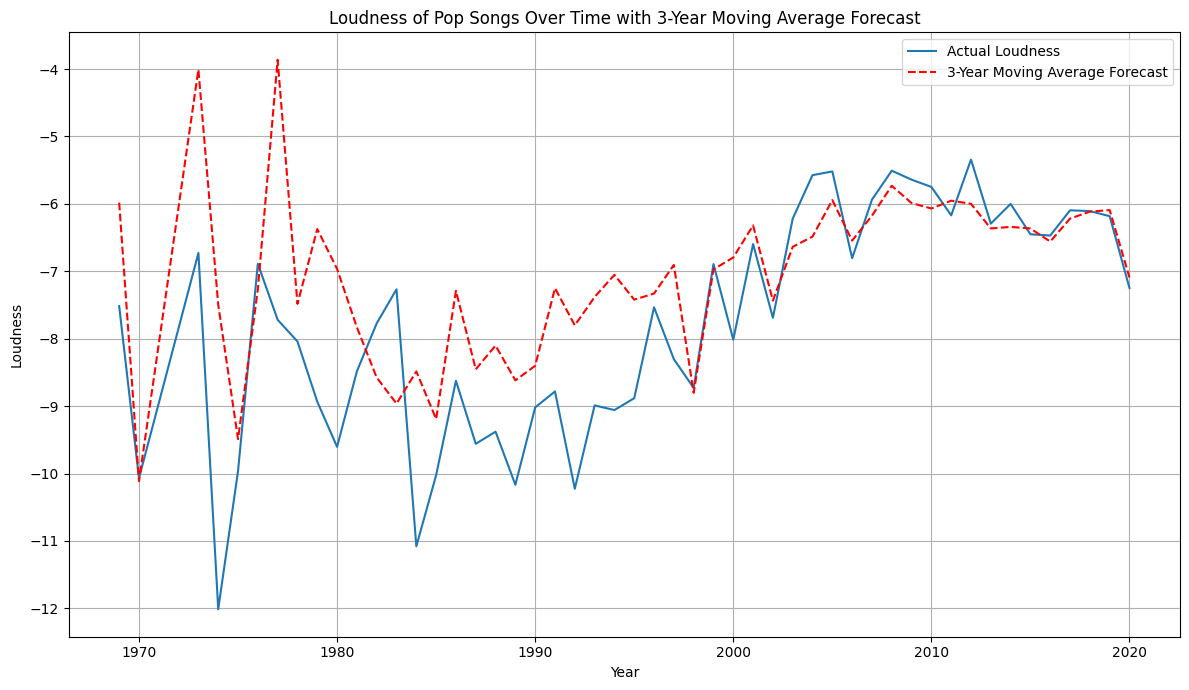

In [ ]:
# Try time series analysis for loudness of pop songs over time
plt.figure(figsize=(12, 7))

# Calculate moving average of loudness with n=3
# Using 'loudness' column and shifting by 1 to get a lagged moving average forecast
df_pop['loudness_ma3'] = df_pop['loudness'].rolling(window=3).mean().shift(1)

# Plot original loudness
sns.lineplot(data=df_pop, x='year', y='loudness', errorbar=None, label='Actual Loudness')

# Plot 3-period moving average of loudness
sns.lineplot(data=df_pop, x='year', y='loudness_ma3', color='red', linestyle='--', label='3-Year Moving Average Forecast', errorbar=None)

plt.title('Loudness of Pop Songs Over Time with 3-Year Moving Average Forecast')
plt.xlabel('Year')
plt.ylabel('Loudness')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# calculate the MAD for the 3-period MA developed in the previous code block

# To calculate Mean Absolute Deviation (MAD) of the forecast error
# MAD = mean(|Actual - Forecast|)
# Here, 'loudness' is the actual value and 'loudness_ma3' is the forecast
mean_absolute_deviation = (df_pop['loudness'] - df_pop['loudness_ma3']).abs().mean()
print(f"Mean Absolute Deviation (MAD) of the 3-Year Moving Average forecast for loudness: {mean_absolute_deviation}")

Mean Absolute Deviation (MAD) of the 3-Year Moving Average forecast for loudness: 1.892710695251938


In [ ]:
# Try out MA for loundness for window size from 3 to 30, report the MAD for each window size
for window_size in range(3, 31, 3):
  df_pop[f'loudness_ma{window_size}'] = df_pop['loudness'].rolling(window=window_size).mean().shift(1)
  # Use a temporary variable for MAD calculation within the loop
  current_mad = (df_pop['loudness'] - df_pop[f'loudness_ma{window_size}']).abs().mean()
  print(f"Mean Absolute Deviation (MAD) of the {window_size}-Year Moving Average forecast for loudness: {current_mad}")

Mean Absolute Deviation (MAD) of the 3-Year Moving Average forecast for loudness: 1.892710695251938
Mean Absolute Deviation (MAD) of the 6-Year Moving Average forecast for loudness: 1.7903160940435072
Mean Absolute Deviation (MAD) of the 9-Year Moving Average forecast for loudness: 1.7659301766298856
Mean Absolute Deviation (MAD) of the 12-Year Moving Average forecast for loudness: 1.7582121474067332
Mean Absolute Deviation (MAD) of the 15-Year Moving Average forecast for loudness: 1.7582960791454234
Mean Absolute Deviation (MAD) of the 18-Year Moving Average forecast for loudness: 1.7509458310560513
Mean Absolute Deviation (MAD) of the 21-Year Moving Average forecast for loudness: 1.7483341145426456
Mean Absolute Deviation (MAD) of the 24-Year Moving Average forecast for loudness: 1.7468501656635664
Mean Absolute Deviation (MAD) of the 27-Year Moving Average forecast for loudness: 1.750276148959178
Mean Absolute Deviation (MAD) of the 30-Year Moving Average forecast for loudness: 1.75

### (7.2) Autocorrelation and Autoregression: High-Level Concepts

In time series analysis, **autocorrelation** refers to the correlation of a time series with its own past values. Essentially, it measures how much the current observation of a variable is linearly related to its previous observations. A high autocorrelation suggests that past values have a strong predictive power for future values.

**Autoregression** builds upon this concept. An **Autoregressive (AR) model** is a linear model that predicts future values of a time series based on a weighted sum of its own past values. The idea is that the variable's past behavior can explain its future behavior. For example, an AR(1) model predicts the current value using only the immediately preceding value, while an AR(p) model uses the past 'p' values. Identifying the degree of autocorrelation helps in determining the appropriate 'p' (order) for an AR model, allowing us to capture the inherent temporal dependencies in the data for forecasting and understanding.

### Autoregression (AR) Models and Partial Autocorrelation Function (PACF)

**Autoregression (AR) Models** are a class of linear models that predict future values based on past observations. An AR model of order `p`, denoted as AR(p), predicts the current value of a time series as a linear combination of its past `p` values. For example, an AR(1) model uses the previous value to predict the current one, while an AR(2) uses the two previous values. These models are fundamental in time series analysis for capturing inherent dependencies and trends within sequential data.

To determine the appropriate order `p` for an AR model, the **Partial Autocorrelation Function (PACF)** is a crucial diagnostic tool. The PACF measures the correlation between a time series and its lagged values, after controlling for the effects of all intermediate lags. In simpler terms, PACF helps identify the direct relationship between an observation and its past values, excluding indirect correlations. A significant spike in the PACF at a particular lag `k` (and then drops to near zero) suggests that the time series can be modeled by an AR(k) process.

In Python, the `statsmodels` library provides the **`AutoReg` model**, which is specifically designed for fitting autoregressive time series models. This model allows you to specify the number of lags (`p`) directly or to use information criteria to automatically select the optimal lag order. Once fitted, the `AutoReg` model can be used for forecasting and to understand the underlying autoregressive structure of the time series.

In [ ]:
yearly_loudness_mean = df_pop.groupby('year')['loudness'].mean().reset_index()
display(yearly_loudness_mean.head())

,year,loudness
0,1969,-7.516
1,1970,-10.068
2,1973,-6.728
3,1974,-12.013
4,1975,-9.965


Next, we will plot PACF and select the p.

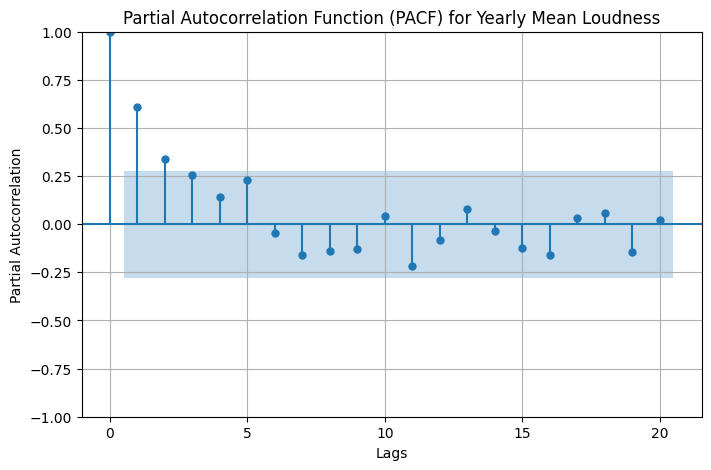

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
import pandas as pd

# Ensure yearly_loudness_mean is grouped by year
yearly_loudness_mean_grouped_by_year = df_pop.groupby('year')['loudness'].mean().reset_index()
yearly_loudness_mean_indexed = yearly_loudness_mean_grouped_by_year.set_index('year')

# Convert integer year index to PeriodIndex with yearly frequency, then to DatetimeIndex
yearly_loudness_mean_indexed.index = pd.PeriodIndex(yearly_loudness_mean_indexed.index, freq='Y')
yearly_loudness_mean_indexed.index = yearly_loudness_mean_indexed.index.to_timestamp()

# Generate PACF plot
plt.figure(figsize=(8, 5))
# Limit lags to a safe maximum: min(20, (sample_size // 2) - 1)
plot_pacf(yearly_loudness_mean_indexed['loudness'], lags=min(20, (len(yearly_loudness_mean_indexed) // 2) - 1), ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Yearly Mean Loudness')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



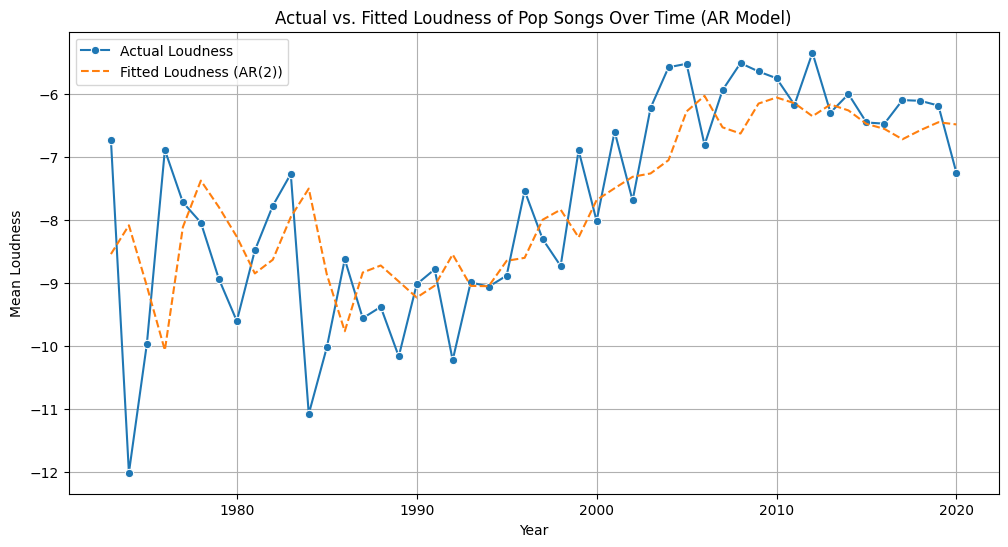

                            AutoReg Model Results                             
Dep. Variable:               loudness   No. Observations:                   50
Model:                     AutoReg(2)   Log Likelihood                 -76.926
Method:               Conditional MLE   S.D. of innovations              1.202
Date:                Thu, 12 Feb 2026   AIC                            161.852
Time:                        18:53:09   BIC                            169.336
Sample:                             2   HQIC                           164.680
                                   50                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.8570      0.916     -2.028      0.043      -3.652      -0.062
loudness.L1     0.4034      0.130      3.104      0.002       0.149       0.658
loudness.L2     0.3489      0.131      2.660    

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import pandas as pd
import seaborn as sns # Ensure seaborn is imported

# Set 'year_month' as index for time series modeling
yearly_loudness_mean_indexed = yearly_loudness_mean.set_index('year')

# Ensure the index is a DatetimeIndex for statsmodels
yearly_loudness_mean_indexed.index = pd.PeriodIndex(yearly_loudness_mean_indexed.index, freq='Y')
yearly_loudness_mean_indexed.index = yearly_loudness_mean_indexed.index.to_timestamp()

# Fit an AR model (e.g., AR(1) for demonstration, but p can be chosen based on PACF or information criteria)
# Using order=2 based on previous PACF plot inspection
model = AutoReg(yearly_loudness_mean_indexed['loudness'], lags=2, seasonal=False)
model_fit = model.fit()

# Get the number of lags used by the model
lags_value = max(model_fit.ar_lags) # Correct way to get the maximum lag from the fitted model

# Use model_fit.fittedvalues for in-sample predictions
fitted_values_series = model_fit.fittedvalues.dropna() # Drop NaNs to get clean fitted series

# Plot actual vs. fitted values
plt.figure(figsize=(12, 6))
# Plot actuals, aligning to the index of the non-NaN fitted values
sns.lineplot(x=fitted_values_series.index, y=yearly_loudness_mean_indexed['loudness'].loc[fitted_values_series.index], label='Actual Loudness', marker='o')
# Plot fitted values
sns.lineplot(x=fitted_values_series.index, y=fitted_values_series, label=f'Fitted Loudness (AR({lags_value}))', linestyle='--')
plt.title('Actual vs. Fitted Loudness of Pop Songs Over Time (AR Model)')
plt.xlabel('Year')
plt.ylabel('Mean Loudness')
plt.legend()
plt.grid(True)
plt.show()

# Display model summary
print(model_fit.summary())

In [ ]:
# Calculate MAD (MAE, mean absolte error) for the AutoReg model (not common as RMSE)

# Ensure the actual values are aligned with the fitted values by starting from lags_value
actual_aligned = yearly_loudness_mean_indexed['loudness'][lags_value:]

# Calculate MAD
mad_ar_model = (actual_aligned - fitted_values_series).abs().mean()

print(f"Mean Absolute Deviation (MAD) for the AR({lags_value}) model: {mad_ar_model}")

Mean Absolute Deviation (MAD) for the AR(2) model: 0.8681284719150724
